## <center>CSCI E-82</center>
## <center>HW 1  Dimensionality Reduction (Ver. 9/5/2026)</center>
### <center>Due: Saturday Sept 19, 2026 11:59pm EST</center>

### Note that this is an individual homework to be completed without collaborations except through Ed Discussion.  If GenAI is used, include comments with the code where it was used.


### Your name:

In [1]:
#### Ayoola Njoku

### Problem 1 Python Linear Algebra  (5 points total)

$$\mathbf{X} = \left[\begin{array}
{rrr}
1 & 2 & 3 \\
4 & -6 & 5 \\
8 & 10 & 6
\end{array}\right]
$$

$$\mathbf{Y} = \left[\begin{array}
{rrr}
1 & 2 & 3 \\
1 & 1 & 1 \\
-3 & -2 & -1  
\end{array}\right]
$$

### Problem 1a (3 points)
Compute YX<sup>T</sup> using any python approach.  We recommend np.array math, but the choice is yours.


In [2]:
import numpy as np

X = np.array([[1,2,3],
             [4,-6,5],
             [8,10,6]])

Y = np.array([[1,2,3],
              [1,1,1],
              [-3,-2,-1]])

In [3]:
# then we transpost 

YX_T = Y @ X.T # np.transpose also works

print("Result of transposing YX to give YX_T\n", YX_T)


Result of transposing YX to give YX_T
 [[ 14   7  46]
 [  6   3  24]
 [-10  -5 -50]]


### Problem 1b (2 points)
Compute X<sup>-1</sup>, the inverse of X. Again, use a python library for this. You don't need to do anything manually, although it is manageable.

In [4]:
#using pinv below allows us to be safe incase we come across a non-square matrix

X_IN = np.linalg.pinv(X)

print("THe inverse of X is, X_IN=\n", X_IN)

THe inverse of X is, X_IN=
 [[-0.40952381  0.08571429  0.13333333]
 [ 0.07619048 -0.08571429  0.03333333]
 [ 0.41904762  0.02857143 -0.06666667]]


## Problem 2 PCA (45 points total)
This problem goes through a combination of python data manipulations as well as the full math projection using PCA. We have divided the problem into multiple parts.

For this problem, you are going to use the numeric data in columns for the NBA (National Basketball Association) found in the tab-delimited nba_statistics.txt file provided.

If you are up for a challenge, load the up-to-date data directly from the site https://www.espn.com/nba/stats/player rather than rely on the previous year's cleaned file.

To interpret the columns, you may find the site https://en.wikipedia.org/wiki/Basketball_statistics useful.

The general goal of the next few problems is perform a visual analysis of this high dimensional dataset to understand whether players have different patterns characterized by position (POS), team, or "experience" (GP).  

### Problem 2a  (5 points)

Load the dataset.  

The full dataset contains text, categories, and numeric data.  We will focus on the numeric data from PTS through TD3 for all the numeric analyses, and color the data by other characteristics.  

The statistics are averages per game, but few players spend the entire 48 minutes in the game.  To correct for this, divide all the columns PTS through TD3 by the MIN minutes column.  Preserve the full set of column (i.e., don't reduce the number of columns).

Note that if you followed the previous step blindly, you probably created some features that make absolutely no sense. Be sure to think through what makes sense.

With this normalized data, standardize it by subtracting the mean and dividing by the standard deviation for all the numeric columns.

Print the first few lines of the resulting matrix.

In [5]:
data= np.genfromtxt('nba_statistics.txt', delimiter='\t',names=True, dtype=None, encoding='latin-1')
numcols = [n for n in data.dtype.names if n not in ('NAME', 'POS')]
M = np.vstack([data[n] for n in numcols]).T.astype(float)           # stack them into a block

MIN  = M[:, numcols.index('MIN')]

i0   = numcols.index('PTS')

pct = ['FG', '3P', 'FT']
rate = [j for j in range(i0, len(numcols)) if numcols[j] not in pct]

Mnorm = M.copy()                          # GP, MIN and the percentages pass through
Mnorm[:, rate] = M[:, rate] / MIN[:, None]

Z = (Mnorm - Mnorm.mean(axis=0)) / Mnorm.std(axis=0, ddof=1) # standardize the normalized matrix

print(Z[:5])


[[ 0.91956492  1.90046543  3.18847815  2.54040931  2.4293677   0.3030888
   1.96195723  1.80468879  0.53128957  2.60004567  2.71835721  0.33143491
   0.68742651  2.71447165  0.1965199  -0.4135262   1.96855271  3.95958728
  10.51505933]
 [ 1.03905521  1.66517352  2.92461927  2.87673294  1.62790577  1.58109765
  -1.0013229  -1.09865142 -0.21205779  2.97392677  3.99288072 -0.26150676
   1.59571588  1.43145838  0.06455434  0.40389352  1.61355482  5.01926676
   5.2674446 ]
 [ 1.1187154   1.54241253  3.06619697  2.62597681  2.03402922  0.7978019
  -0.25276043 -0.3852773   0.33168704  3.4999911   3.14124931  0.73592226
  -0.24539106  1.39286888  1.07116354  0.18584038  0.49015372  0.32835104
  -0.1357831 ]
 [ 1.19837559  1.68563369  2.57879721  2.27679004  2.2205624   0.22063662
   0.93206496  0.68264941  0.66206364  2.04624836  1.86160377  0.61181819
  -0.91590771  1.50853943 -0.28819693 -0.76407908  0.59904894  0.39255572
  -0.1357831 ]
 [ 1.1187154   1.86977518  2.04119174  1.90512907  1.4

### Problem 2b  (5 points)

For the numeric data only (GP through TD3), compute and print the covariance matrix. Rather than use the built-in function, compute this using python code for practice.  The following equation will suffice for this.  We encourage you to check the result using the built-in function.

Cov(X, Y) = Σ ( Xi - X ) ( Yi - Y ) / (N-1) 


In [6]:
# Using the standardized Z-scores for further analysis

playerCount, featureCount = Z.shape
print("Shape of Z:")
print(Z.shape)
columnMean = Z.mean(axis=0) # Mean of each feature used for centering the Z-scores
print("Shape of column mean vector:")
print(columnMean.shape)
covMatrix = np.zeros((featureCount, featureCount))

for i in range(featureCount):
    for j in range(featureCount):
        covMatrix[i, j] = np.sum((Z[:, i] - columnMean[i]) * (Z[:, j] - columnMean[j])) / (playerCount - 1)

autoCovMatrix = np.cov(Z, rowvar=False)

print("Covariance matrix calculated manually:")
print(covMatrix)




Shape of Z:
(562, 19)
Shape of column mean vector:
(19,)
Covariance matrix calculated manually:
[[ 1.          0.68804029  0.2982135   0.25995106  0.1171319   0.27931499
   0.22799317  0.07539228  0.31964733  0.15458571  0.1264869   0.38752548
  -0.03598276  0.1202861  -0.09860189 -0.04950113  0.01477774  0.37902671
   0.14347565]
 [ 0.68804029  1.          0.4665771   0.4074639   0.29594252  0.2218012
   0.25727071  0.12092866  0.27962287  0.31016117  0.26302061  0.37023647
  -0.05514807  0.27177644 -0.06067649 -0.06726943  0.14729376  0.47899497
   0.21183267]
 [ 0.2982135   0.4665771   1.          0.94522503  0.86228454  0.29714414
   0.35067365  0.31777264  0.20821445  0.62353343  0.59393021  0.23357315
   0.13901389  0.26296678 -0.01841939 -0.06386216  0.28628175  0.39512869
   0.22105001]
 [ 0.25995106  0.4074639   0.94522503  1.          0.86728019  0.41821656
   0.19648011  0.19351243  0.10457176  0.42038775  0.42144958  0.079758
   0.23222482  0.18911653 -0.07075822 -0.0032507

In [7]:
print("\nCovariance matrix calculated using np.cov:")
print(autoCovMatrix)


Covariance matrix calculated using np.cov:
[[ 1.          0.68804029  0.2982135   0.25995106  0.1171319   0.27931499
   0.22799317  0.07539228  0.31964733  0.15458571  0.1264869   0.38752548
  -0.03598276  0.1202861  -0.09860189 -0.04950113  0.01477774  0.37902671
   0.14347565]
 [ 0.68804029  1.          0.4665771   0.4074639   0.29594252  0.2218012
   0.25727071  0.12092866  0.27962287  0.31016117  0.26302061  0.37023647
  -0.05514807  0.27177644 -0.06067649 -0.06726943  0.14729376  0.47899497
   0.21183267]
 [ 0.2982135   0.4665771   1.          0.94522503  0.86228454  0.29714414
   0.35067365  0.31777264  0.20821445  0.62353343  0.59393021  0.23357315
   0.13901389  0.26296678 -0.01841939 -0.06386216  0.28628175  0.39512869
   0.22105001]
 [ 0.25995106  0.4074639   0.94522503  1.          0.86728019  0.41821656
   0.19648011  0.19351243  0.10457176  0.42038775  0.42144958  0.079758
   0.23222482  0.18911653 -0.07075822 -0.00325077  0.30107226  0.40739122
   0.21320943]
 [ 0.117131

### Problem 2c  (10 points)

Compute the decomposition of the covariance matrix using singular value decomposition (SVD).  Using a python function is definitely the way to go here.  Print out the 3 matrices.

In [8]:
# SVD helps provide a decomposition of the covariance matrix they are also called eigen vectors and eigen values. The left singular vectors correspond to the eigen vectors of the covariance matrix, and the singular values correspond to the square roots of the eigen values.
leftUVectors, singularValues, rightVVectorsT = np.linalg.svd(covMatrix)



print('U  (left singular vectors):\n', leftUVectors)
print('S  (singular values):\n', np.diag(singularValues))
print('V^T (right singular vectors):\n', rightVVectorsT)

U  (left singular vectors):
 [[-2.20177825e-01  6.47671458e-02 -4.84261967e-01 -1.36039669e-01
  -3.25415887e-02  1.44041670e-01 -1.72608902e-01  2.32985262e-02
   2.84420819e-01 -1.06998917e-01 -2.05070068e-01 -3.86446988e-03
   3.82170382e-02  6.73330510e-01  2.27642038e-01 -2.08222787e-02
  -2.56818733e-02 -2.32374055e-03 -5.53773737e-04]
 [-2.96967546e-01  6.02274728e-02 -3.41043614e-01 -1.43885059e-01
  -9.40772764e-02  1.02816466e-01 -2.35282099e-01  4.27992767e-03
   2.68853642e-01 -2.10974279e-01 -9.49837647e-02  1.59291571e-01
   1.35432919e-01 -4.54700517e-01 -5.60800765e-01  7.35147446e-02
   1.29136019e-02 -4.44569710e-03  5.51384089e-04]
 [-4.16494292e-01  3.06878740e-02  1.10095635e-01  2.15472972e-01
   1.04920620e-01  7.64797213e-02  6.97770631e-02  7.69175698e-02
  -5.06766416e-02  2.96331654e-02  1.89109629e-02  6.19223666e-02
   2.34427418e-02 -4.20815725e-03  2.57719531e-02 -2.23038393e-01
  -1.46390592e-01 -2.25662494e-01 -7.80018505e-01]
 [-3.75523503e-01 -3.13871

In [9]:

print("U  shape:", leftUVectors.shape)
print("S  shape:", singularValues.shape)
print("Vt shape:", rightVVectorsT.shape)

U  shape: (19, 19)
S  shape: (19,)
Vt shape: (19, 19)


In [10]:
print("Column mean vector:")
print(columnMean)

Column mean vector:
[-7.12162634e-16  3.31091422e-16 -2.37611433e-15 -2.56813155e-16
  9.60876297e-16 -1.75028043e-15 -1.34372545e-15  4.52188702e-16
  3.19080468e-15 -2.11969627e-16  4.53571542e-16 -1.60350183e-15
 -2.16236677e-15 -1.09856766e-15  8.26753158e-16  2.37058297e-17
  2.93952288e-16 -2.22577986e-15  1.20307086e-15]


### Problem 2d  (10 points)

Compute the projection of the raw data onto the appropriate two eigenvectors.  Consider which columns should be projected and the normalizations.

Try coloring the data by 3 different variables:  position (POS), team, and games played (GP).  Note that for the team, there are too many teams to represent using color.  Using the https://www.espn.com/nba/standings, divide the teams from each conference into the top 6, 7-10th, and bottom 5 so there will be 6 different colors.  Which has the clearest pattern?

In [11]:
topUVectors = leftUVectors[:, :2]  # Taking the top 2 left singular vectors/eigen vectors
scores = Z @ topUVectors # Projecting the standardized data onto the top 2 left singular vectors by matrix multiplication

print("shape of the Top 2 left singular vectors (U):")
print(topUVectors.shape)

print("shape of standardized Z-scores:")
print(Z.shape)


print("Shape of the scores matrix:")
print(scores.shape)

pc1 = scores[:, 0] # first projection (principal component)
pc2 = scores[:, 1] # second projection (principal component)

# Setting up positions

positions = np.char.upper(data['POS'])

posMap= {'PG':'Guard', 'SG':'Guard', 'G':'Guard', 'SF':'Forward', 'PF':'Forward','F': 'Forward', 'C':'Center'} # This allows us group positions into broader categories for presentation
broadPositions = np.array([posMap[pos] for pos in positions])
posColors = {'Guard':'#2a78d6', 'Forward':'#eb6834', 'Center':'#1baf7a'}

# Setting up teams

teamFixes = {'DFT':'DET', 'DALVCHA':'DAL/CHA'} # Correcting teams names that were resulting in more teams than 30
def finalTeam(name):
    code = teamFixes.get(name.split()[-1].upper(), name.split()[-1].upper())
    return code.split('/')[-1]
teamCode = np.array([finalTeam(n) for n in data['NAME']]) 
print("Team codes:")
print(teamCode)


#bucketing the teams 
eastOrder = ['BOS','NY','MIL','CLE','ORL','IND','PHI','MIA','CHI','ATL','BKN','TOR','CHA','WSH','DET']
westOrder = ['OKC','DEN','MIN','LAC','DAL','PHX','NO','LAL','SAC','GS','HOU','UTAH','MEM','SA','POR']

def bucket(order, conf):
    return {t: f'{conf} ' + ('top 6' if i < 6 else '7-10' if i < 10 else 'bottom 5')
            for i, t in enumerate(order)}

teamBucketMap = {**bucket(eastOrder, 'East'), **bucket(westOrder, 'West')}
teamBucket    = np.array([teamBucketMap[t] for t in teamCode])

print("Team bucket assignments:")
print(teamBucket)
print(teamBucket.shape)

shape of the Top 2 left singular vectors (U):
(19, 2)
shape of standardized Z-scores:
(562, 19)
Shape of the scores matrix:
(562, 2)
Team codes:
['DAL' 'MIL' 'OKC' 'NY' 'PHX' 'PHX' 'BOS' 'SAC' 'GS' 'DEN' 'PHI' 'MIN'
 'LAL' 'DAL' 'LAL' 'MIL' 'CHI' 'LAC' 'BOS' 'NO' 'DET' 'LAC' 'ORL' 'MEM'
 'ATL' 'BKN' 'WSH' 'MIN' 'TOR' 'SA' 'DEN' 'HOU' 'CHA' 'NO' 'MIA' 'NY'
 'IND' 'NO' 'TOR' 'CHA' 'ORL' 'HOU' 'BKN' 'SA' 'SAC' 'MIA' 'CHI' 'OKC'
 'UTAH' 'CHI' 'LAL' 'GS' 'HOU' 'WSH' 'CHA' 'PHI' 'IND' 'NY' 'ATL' 'DEN'
 'LAC' 'OKC' 'CLE' 'GS' 'LAL' 'SA' 'NY' 'PHI' 'SAC' 'DET' 'SAC' 'BOS'
 'UTAH' 'WSH' 'IND' 'DAL' 'BKN' 'CLE' 'POR' 'MIN' 'LAC' 'DEN' 'DET' 'MIL'
 'HOU' 'TOR' 'ATL' 'LAL' 'PHX' 'MIN' 'BKN' 'WSH' 'GS' 'UTAH' 'MIA' 'CHA'
 'HOU' 'ORL' 'MIL' 'BOS' 'OKC' 'NO' 'SAC' 'CLE' 'IND' 'CHI' 'PHI' 'WSH'
 'MIA' 'BKN' 'LAC' 'SA' 'ORL' 'ATL' 'MIN' 'MIL' 'SA' 'LAC' 'PHX' 'NO'
 'DAL' 'PHX' 'OKC' 'ORL' 'TOR' 'MEM' 'MIN' 'DET' 'BKN' 'DET' 'CHA' 'IND'
 'IND' 'SAC' 'DEN' 'DEN' 'CHI' 'SA' 'MIA' 'IND' 'TOR' 'BKN' 'CHA' '

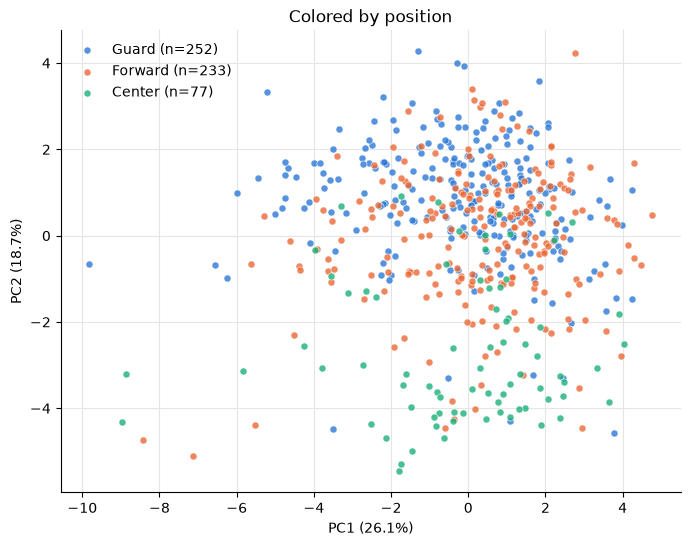

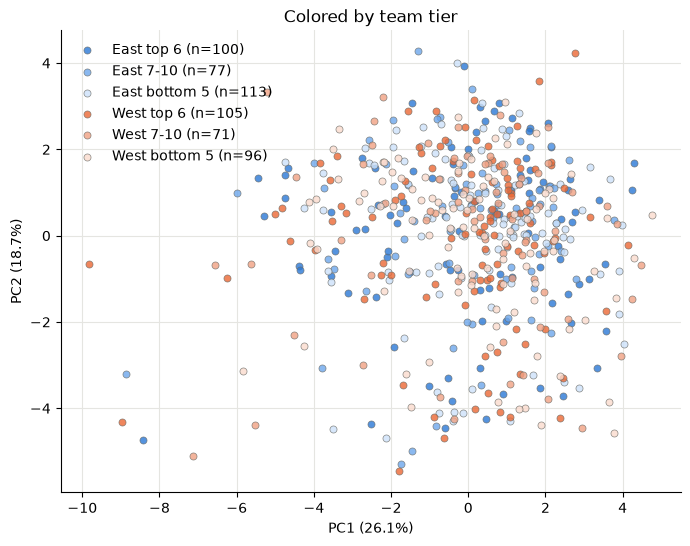

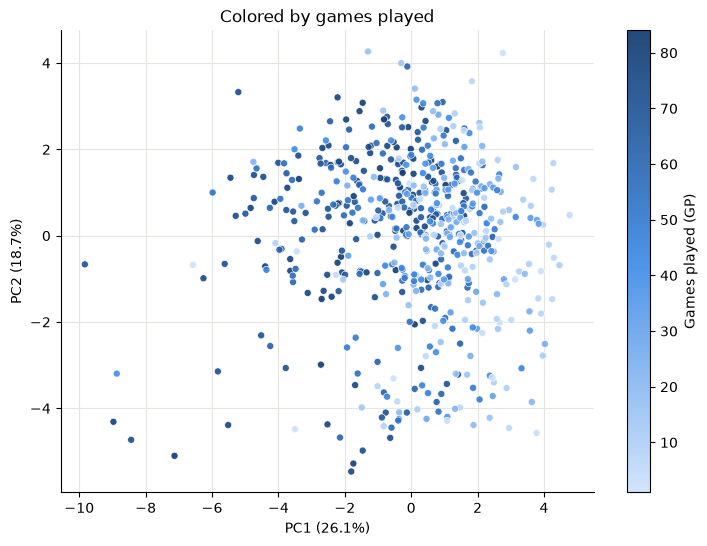

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

varianceRatio = singularValues / singularValues.sum() 
gamesPlayed = M[:, numcols.index('GP')]



xlab = 'PC1 (%.1f%%)' % (100*varianceRatio[0])
ylab = 'PC2 (%.1f%%)' % (100*varianceRatio[1])

def dress(ax, title):
    ax.set_xlabel(xlab); ax.set_ylabel(ylab); ax.set_title(title)
    ax.grid(color='#e5e5e1', linewidth=0.8, zorder=0); ax.set_axisbelow(True)
    for s in ('top','right'): ax.spines[s].set_visible(False)

fig, ax = plt.subplots(figsize=(8,6))
for g in ['Guard','Forward','Center']:
    m = broadPositions == g
    ax.scatter(pc1[m], pc2[m], s=26, c=posColors[g], label=f'{g} (n={m.sum()})',
               alpha=.8, linewidths=.5, edgecolors='white', zorder=3)
dress(ax, 'Colored by position'); ax.legend(frameon=False)

# by team tier — conference by hue, tier by lightness
teamColors = {'East top 6':'#2a78d6','East 7-10':'#6da7ec','East bottom 5':'#cde2fb',
              'West top 6':'#eb6834','West 7-10':'#f0a183','West bottom 5':'#fbdbce'}
fig, ax = plt.subplots(figsize=(8,6))
for team, color in teamColors.items():
    m = teamBucket == team
    ax.scatter(pc1[m], pc2[m], s=26, c=color, label=f'{team} (n={m.sum()})',
               alpha=.8, linewidths=.5, edgecolors='#6b6b66', zorder=3)
dress(ax, 'Colored by team tier'); ax.legend(frameon=False)

# by GP — continuous, so one-hue ramp + colorbar
blues = LinearSegmentedColormap.from_list('blues', ['#cde2fb','#3987e5','#0d366b'])
fig, ax = plt.subplots(figsize=(8.6,6))
sc = ax.scatter(pc1, pc2, s=26, c=gamesPlayed, cmap=blues, alpha=.9,
                linewidths=.5, edgecolors='white', zorder=3)
fig.colorbar(sc, ax=ax, label='Games played (GP)')
dress(ax, 'Colored by games played')




In [13]:
## In terms of which of the plaot has the clearest pattern, I am strugling to see it
## I know for sure that the plotting of team tiers does not allude to much. 

## We can make a case in Positions, where we see distinct clusters for Guards, Forwards, and Centers.
## With forwards separating the guards and centers more clearly.

## I think overall the clearest pattern would be games played, we start to see lower games played as we shift to
## right of the graph. Higher games played are cenetred around the middle of the graph.

### Problem 2e (5 points)

All PCA plots require a qualification of the fraction of variance captured in the plot.  Compute this here either numerically or (preferred) graphically.

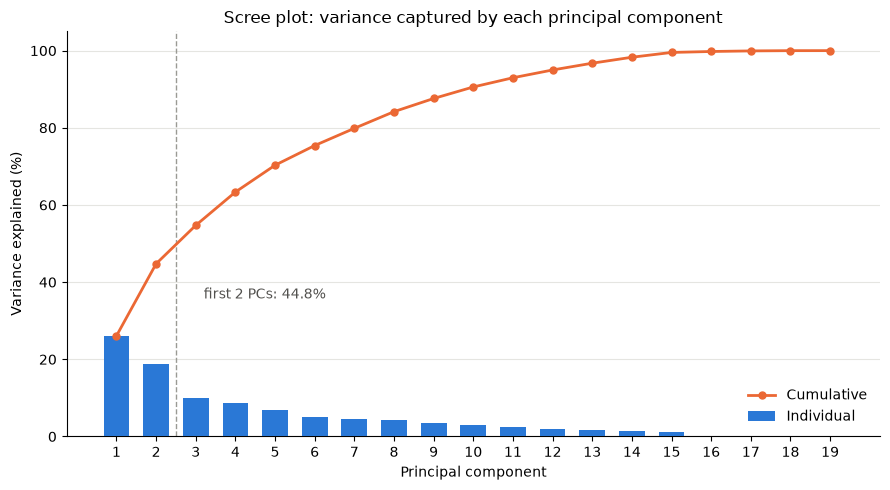

In [14]:
cumulativeVar  = np.cumsum(varianceRatio)
componentIndex = np.arange(1, len(varianceRatio) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(componentIndex, 100*varianceRatio, color='#2a78d6', width=0.65,
       label='Individual', zorder=3)
ax.plot(componentIndex, 100*cumulativeVar, color='#eb6834', marker='o',
        markersize=5, linewidth=2, label='Cumulative', zorder=4)
ax.axvline(2.5, color='#9a9a94', linestyle='--', linewidth=1, zorder=2)
ax.annotate('first 2 PCs: %.1f%%' % (100*cumulativeVar[1]),
            xy=(2, 100*cumulativeVar[1]), xytext=(3.2, 100*cumulativeVar[1]-9),
            color='#52514e', fontsize=10)

ax.set_xlabel('Principal component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree plot: variance captured by each principal component')
ax.set_xticks(componentIndex)
ax.set_ylim(0, 105)
ax.grid(axis='y', color='#e5e5e1', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


In [15]:
for k in range(5):
    print('PC%-2d  %5.1f%%   cumulative %5.1f%%'
          % (k+1, 100*varianceRatio[k], 100*cumulativeVar[k]))
print('\nComponents for 80%%: %d' % (np.searchsorted(cumulativeVar, 0.80) + 1)) # how many components are needed to explain 80% of the variance
print('Components for 90%%: %d' % (np.searchsorted(cumulativeVar, 0.90) + 1)) # how many components are needed to explain 90% of the variance


PC1    26.1%   cumulative  26.1%
PC2    18.7%   cumulative  44.8%
PC3    10.0%   cumulative  54.7%
PC4     8.6%   cumulative  63.4%
PC5     7.0%   cumulative  70.3%

Components for 80%: 8
Components for 90%: 10


### Problem 2f (5 points)

Which features are the dominant characteristics that define the first principal component?  A plot is optional.

In [16]:
pc1Loadings = leftUVectors[:, 0]
order = np.argsort(-np.abs(pc1Loadings))     # sort by magnitude, ignoring sign

print('PC1 loadings, by magnitude:')
for k in order:
    print('  %-5s %+.3f' % (numcols[k], pc1Loadings[k]))


PC1 loadings, by magnitude:
  PTS   -0.416
  FGM   -0.376
  FGA   -0.332
  FTM   -0.316
  FTA   -0.300
  MIN   -0.297
  DD2   -0.264
  GP    -0.220
  AST   -0.182
  TD3   -0.172
  FT    -0.167
  TO    -0.164
  3PM   -0.134
  FG    -0.123
  3PA   -0.106
  3P    -0.106
  REB   -0.067
  BLK   +0.027
  STL   -0.007


For the first principal component pc1, Points and Feild goals made are the top two statistics. 
And from there the numbers gradually distributes till it reaches Steals at -

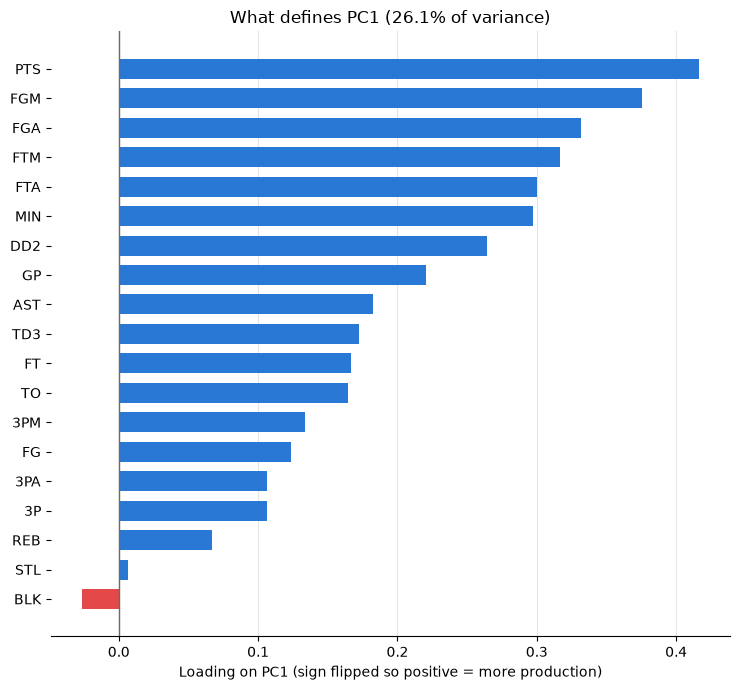

In [17]:
flip   = -pc1Loadings
ordAsc = np.argsort(flip)
vals   = flip[ordAsc]
colors = ['#2a78d6' if v >= 0 else '#e34948' for v in vals]

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.barh(range(len(vals)), vals, color=colors, height=.68, zorder=3)
ax.set_yticks(range(len(vals)))
ax.set_yticklabels([numcols[k] for k in ordAsc])
ax.axvline(0, color='#6b6b66', linewidth=1, zorder=4)
ax.set_xlabel('Loading on PC1 (sign flipped so positive = more production)')
ax.set_title('What defines PC1 (%.1f%% of variance)' % (100*varianceRatio[0]))
ax.grid(axis='x', color='#e5e5e1', linewidth=.8, zorder=0)
ax.set_axisbelow(True)
for s in ('top','right','left'):
    ax.spines[s].set_visible(False)
fig.tight_layout()


#With PC1 we see how much it contributes to the overall variance in the data, and which features are most influential in defining this principal component.
# PTS, FGM and FGA being the top contributors to PC1.


In [18]:
(pc1Loadings**2).sum()

np.float64(1.0000000000000018)

### Problem 2g (5 points)

We asked that the data be standardized.  Why is this important in the analysis described above?

We standardize the data primarily because of what we are studying. We are studing how these features  relate to each other and how they presentation is impacted in a lower dimesional space. 
For eample we want to capture variance in PCA while reducing dimensions. We want to believe that even with a lower dimention we are telling a story that is consistent in a higher dimension.
If we had features that were widely different in scales, a column with a lager numbers will automatically generate more variance and may end up masking its true importance in the dataset which is what PCA cares mostly about, and which we way we sort the eigenvectors(V) by thier eigenvalues.

### Optional Task -- Experiment with PCA Correlation Circle

Specifically, apply the correlation circle method using code available on the web.  Is there any redundancy in the current NBA statistics?

## Problem 3  MDS (5 points)

For the same data set, repeat 2d using sklearn's Multidimensional scaling algorithm. Color by POS as in Problem 2g.  How does MDS compare to PCA?

In [19]:
#MDS attempts to calculate a value called stress, which measures how well the distances in the low-dimensional embedding match the original distances.
# The lower the stress, the better the MDS embedding preserves the original distances.

from sklearn.manifold import MDS

mds = MDS(n_components=2, random_state=42,
          normalized_stress='auto', init='random')
mdsCoords = mds.fit_transform(Z)      # same standardized matrix as PCA

print(mdsCoords.shape)                # (562, 2)
print('stress:', mds.stress_)


(562, 2)
stress: 254431.4264878453


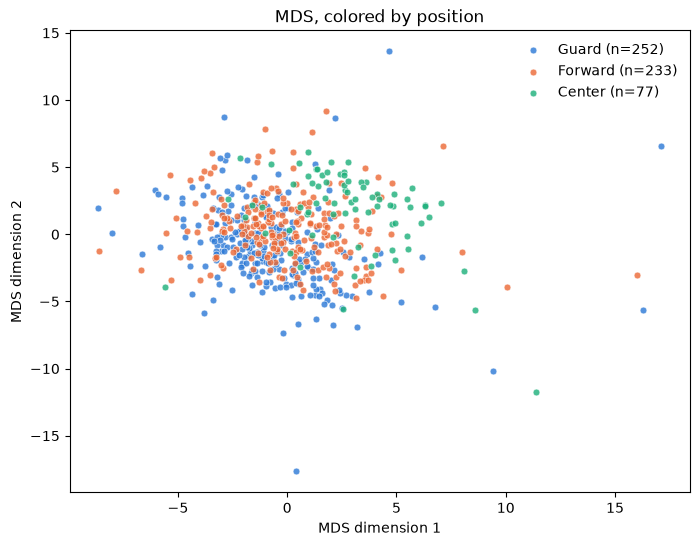

In [20]:
cols = {'Guard':'#2a78d6','Forward':'#eb6834','Center':'#1baf7a'}
fig, ax = plt.subplots(figsize=(8,6))
for g in ['Guard','Forward','Center']:
    m = broadPositions == g
    ax.scatter(mdsCoords[m,0], mdsCoords[m,1], s=24, c=cols[g],
               label=f'{g} (n={m.sum()})', alpha=.8,
               linewidths=.5, edgecolors='white', zorder=3)
ax.set_xlabel('MDS dimension 1'); ax.set_ylabel('MDS dimension 2')
ax.set_title('MDS, colored by position')
ax.legend(frameon=False)


In [21]:
# With both MDA and PCA we see the same thing from different lenses. 
# With both PCA and MDS we see that player positions are somewhat disctinctive 
# in that Center and Guards are clustered at the ends of the scatter with forwards separating them. 
# We do not need to read too much into the fact that the potsitions are flipped for both.

## Problem 4  t-SNE  (10 points)
### Problem 4a t-SNE  (5 points)

For the same data set, apply t-SNE using the default setting. Use the POS coloring scheme.  

t-SNE computation time: 0.8047628402709961 seconds
perplexity: 30.0
KL divergence: 1.0240535736083984


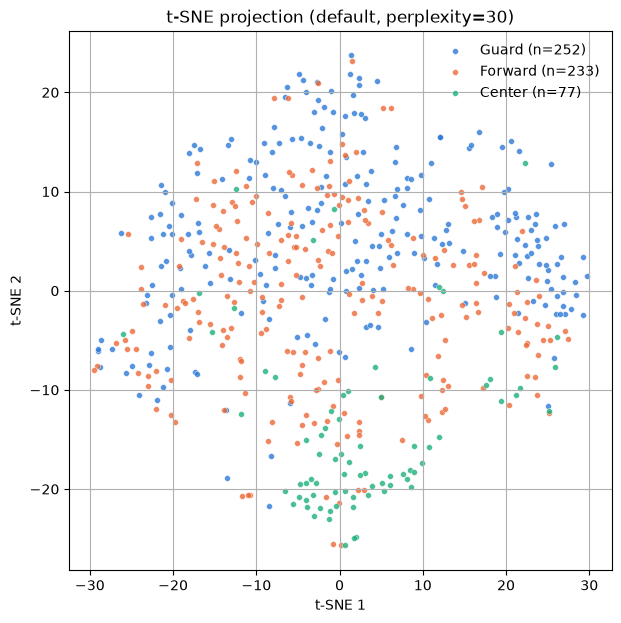

In [22]:
from sklearn.manifold import TSNE
import time

#Defaults from the sklearn.manifold.TSNE class  https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html#sklearn.manifold.TSNE
# class sklearn.manifold.TSNE(n_components=2, *, perplexity=30.0, 
# early_exaggeration=12.0, learning_rate='auto', 
# max_iter=1000, n_iter_without_progress=300, min_grad_norm=1e-07, metric='euclidean', 
# metric_params=None, init='pca', verbose=0, random_state=None, method='barnes_hut', 
# angle=0.5, n_jobs=None)[source]

posColors = {'Guard':'#2a78d6', 'Forward':'#eb6834', 'Center':'#1baf7a'}

tsne = TSNE(n_components=2, random_state=42)
start_time = time.time()
tsneCoords = tsne.fit_transform(Z)
end_time = time.time()
print('t-SNE computation time:', end_time - start_time, 'seconds')

print('perplexity:', tsne.perplexity)          # default is 30
print('KL divergence:', tsne.kl_divergence_)   # default is  1.024

plt.figure(figsize=(7, 7))
for g in ['Guard', 'Forward', 'Center']:
    m = broadPositions == g
    plt.scatter(tsneCoords[m, 0], tsneCoords[m, 1], s=18, c=posColors[g],
                label=f'{g} (n={m.sum()})', alpha=0.8,
                linewidths=0.4, edgecolors='white')
plt.title('t-SNE projection (default, perplexity=30)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(frameon=False)
plt.grid(True)
plt.show()


### Problem 4b t-SNE perplexity (5 points)
Try out a few t-SNE plots for the same data set by varying the perplexity or other parameters. Plot with the POS coloring scheme.  State the best perplexity for providing an interpretation.  Describe your rationale in a sentence or two.

t-SNE computation time for perplexity=5: 0.7681398391723633 seconds


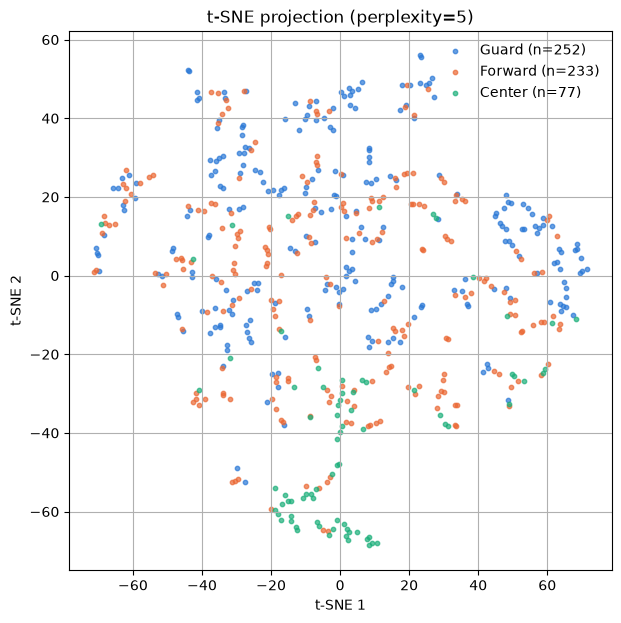

t-SNE computation time for perplexity=15: 0.7525629997253418 seconds


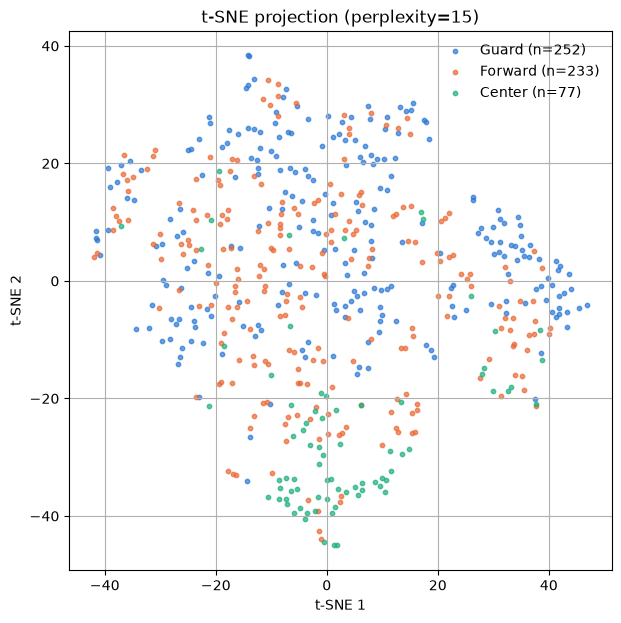

t-SNE computation time for perplexity=30: 0.7798399925231934 seconds


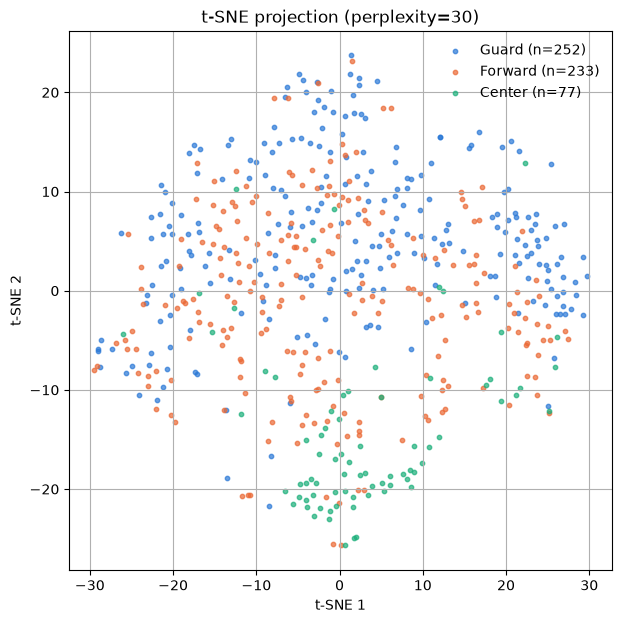

t-SNE computation time for perplexity=50: 0.7941410541534424 seconds


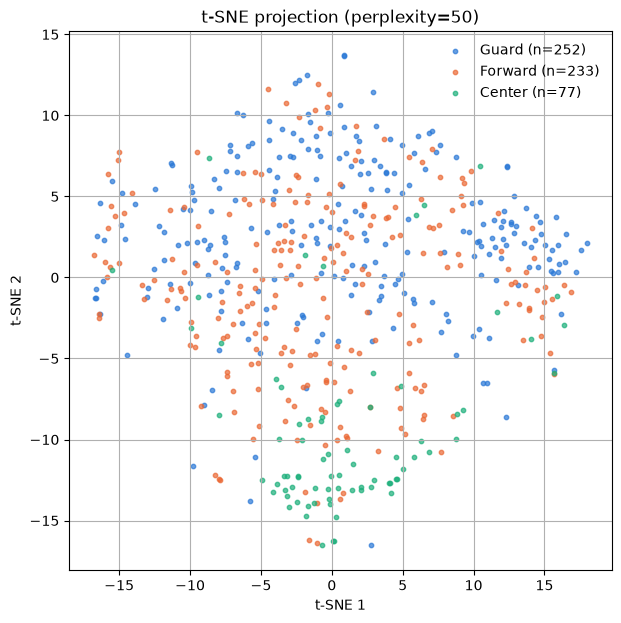

t-SNE computation time for perplexity=100: 0.9706108570098877 seconds


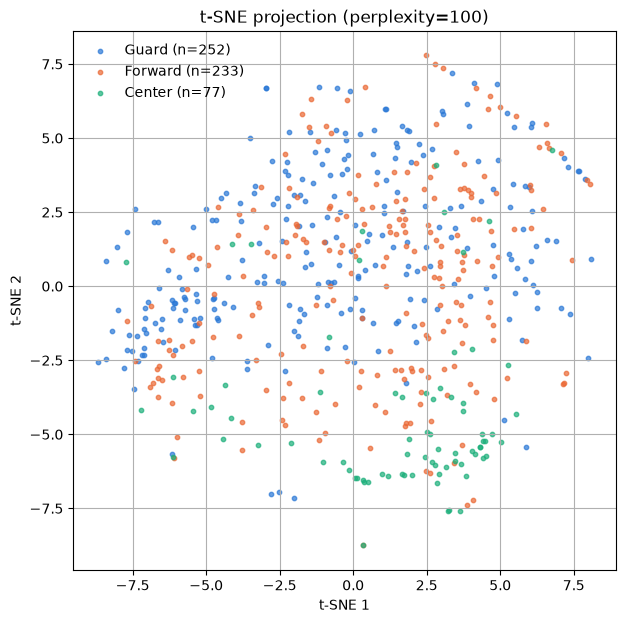

In [23]:

for p in [5, 15, 30, 50, 100]:
    start_time = time.time()
    emb = TSNE(n_components=2, perplexity=p, random_state=42).fit_transform(Z)
    end_time = time.time()
    print(f't-SNE computation time for perplexity={p}:', end_time - start_time, 'seconds')
    plt.figure(figsize=(7, 7))
    for g in ['Guard', 'Forward', 'Center']:
        m = broadPositions == g
        plt.scatter(emb[m, 0], emb[m, 1], s=10, c=posColors[g],
                    label=f'{g} (n={m.sum()})', alpha=0.7)
    plt.title(f't-SNE projection (perplexity={p})')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(frameon=False)
    plt.grid(True)
    plt.show()

In [24]:
# I would use the default choice of perplexity =30, 
# as anything below that makes the presentation look dense.

## Problem 5 UMAP (10 points)
### Problem 5a (5 points)

Show the default UMAP visualization for this data set and then tune the results using the POS, team and GP coloring schemes.  

/Users/ayoolanjoku/opt/anaconda3/envs/py_313_conda/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


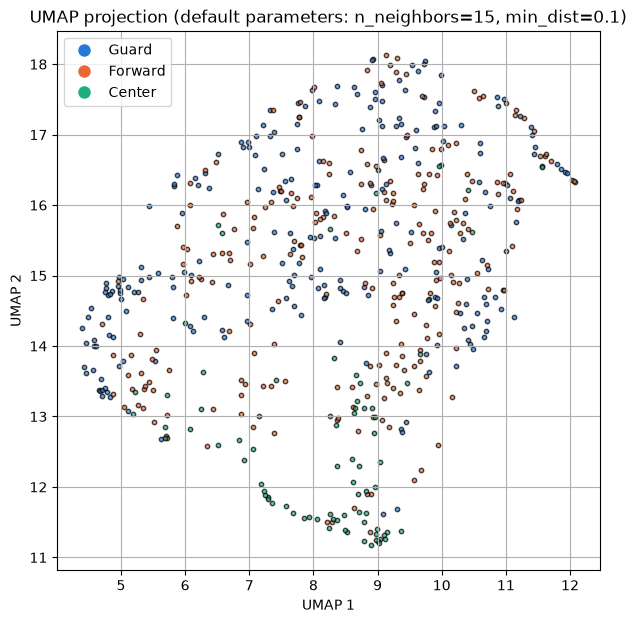

In [25]:
import umap

defaultEmb = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(Z)
plt.figure(figsize=(7, 7))
for g in ['Guard', 'Forward', 'Center']:
    mask = broadPositions == g
    plt.scatter(defaultEmb[mask, 0], defaultEmb[mask, 1], s=10, alpha=0.7, edgecolor='k', c=posColors[g], label=g)
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=posColors[g], markersize=10) for g in ['Guard', 'Forward', 'Center']],
           labels=['Guard', 'Forward', 'Center'])
plt.title('UMAP projection (default parameters: n_neighbors=15, min_dist=0.1)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()


/Users/ayoolanjoku/opt/anaconda3/envs/py_313_conda/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


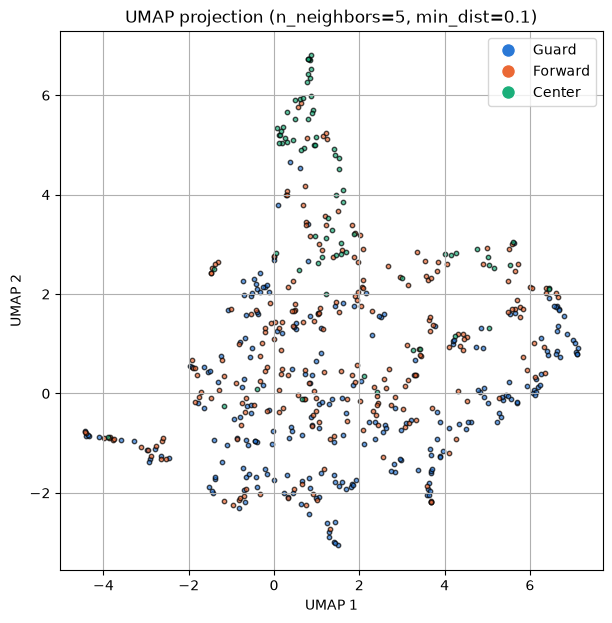

/Users/ayoolanjoku/opt/anaconda3/envs/py_313_conda/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


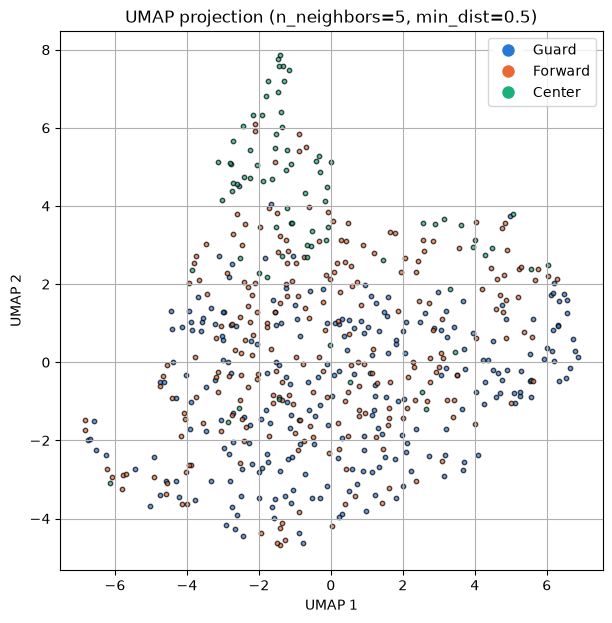

/Users/ayoolanjoku/opt/anaconda3/envs/py_313_conda/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


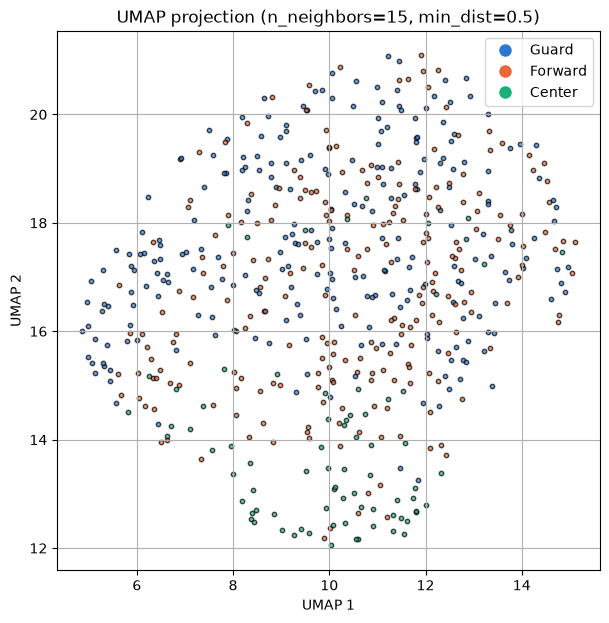

/Users/ayoolanjoku/opt/anaconda3/envs/py_313_conda/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


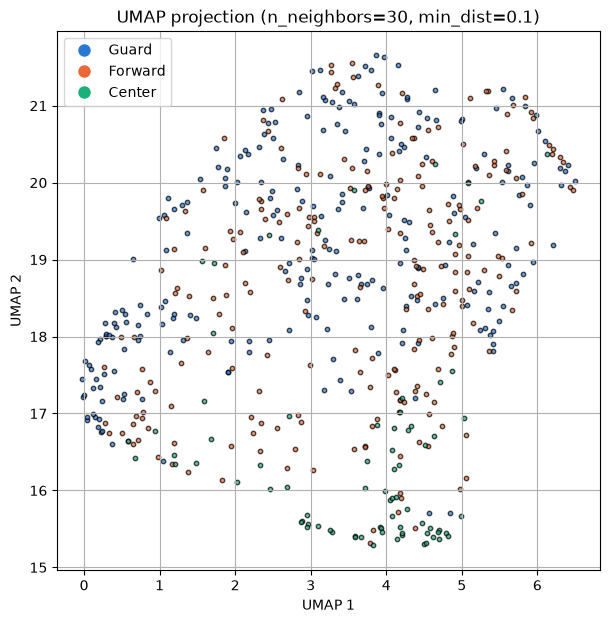

/Users/ayoolanjoku/opt/anaconda3/envs/py_313_conda/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


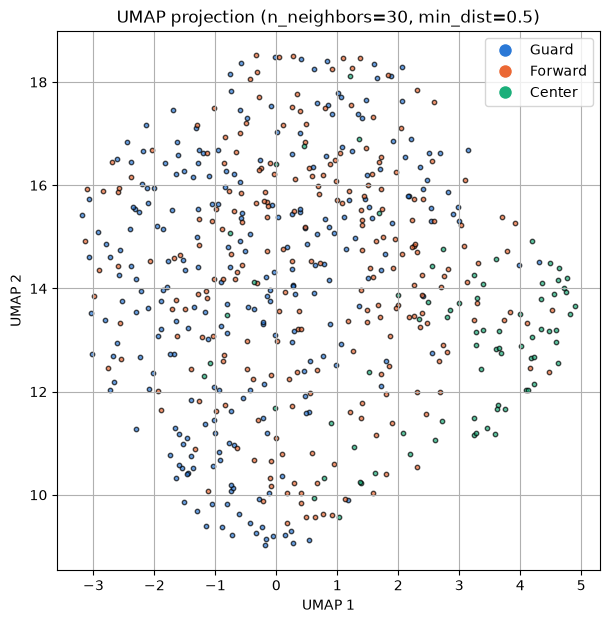

/Users/ayoolanjoku/opt/anaconda3/envs/py_313_conda/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


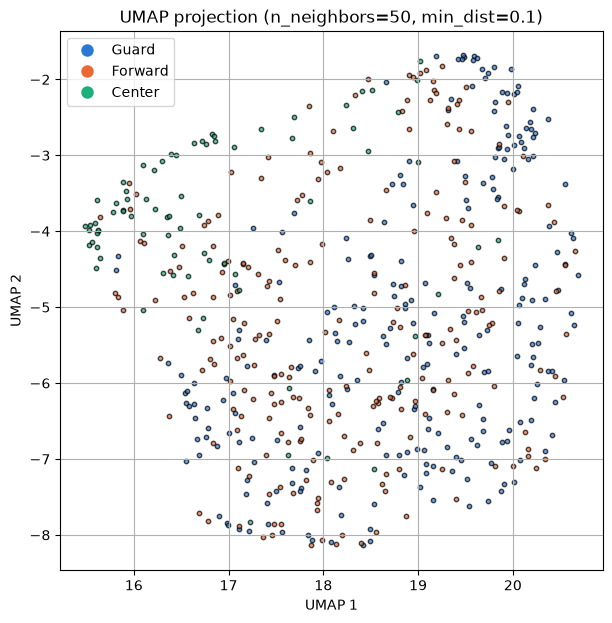

/Users/ayoolanjoku/opt/anaconda3/envs/py_313_conda/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


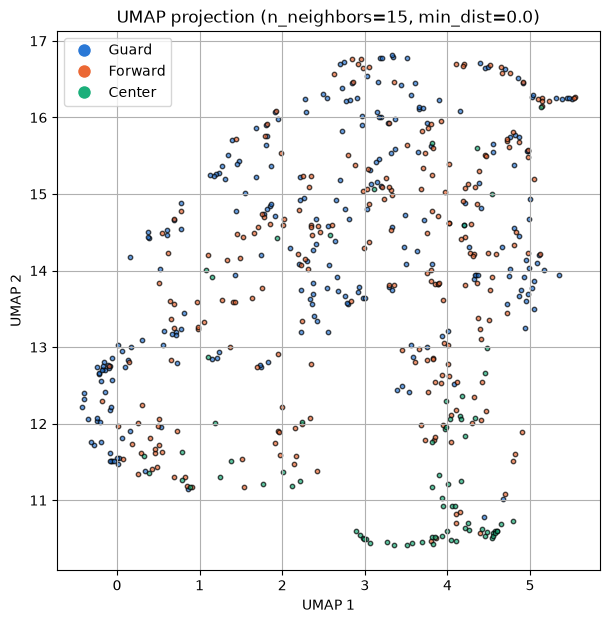

/Users/ayoolanjoku/opt/anaconda3/envs/py_313_conda/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


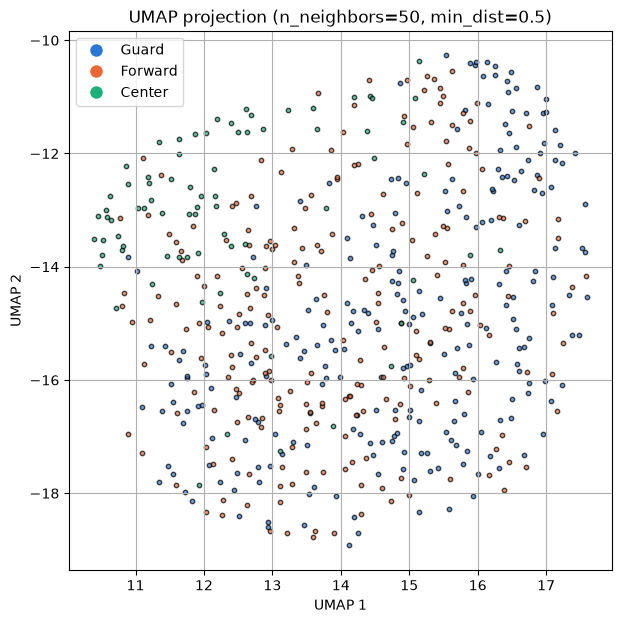

In [26]:

for nn, md in [(5,0.1), (5,0.5), (15,0.5), (30,0.1),(30,0.5), (50,0.1), (15,0.0), (50,0.5)]: # different hyperparameters (number of neighbors, minimum distance)
    emb = umap.UMAP(n_neighbors=nn, min_dist=md, random_state=42).fit_transform(Z)
    plt.figure(figsize=(7, 7))
    for g in ['Guard', 'Forward', 'Center']:
        mask = broadPositions == g
        plt.scatter(emb[mask, 0], emb[mask, 1], s=10, alpha=0.7, edgecolor='k', c=posColors[g], label=g)
    plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=posColors[g], markersize=10) for g in ['Guard', 'Forward', 'Center']],
               labels=['Guard', 'Forward', 'Center'])
    plt.title(f'UMAP projection (n_neighbors={nn}, min_dist={md})')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.grid(True)
    plt.show()

/Users/ayoolanjoku/opt/anaconda3/envs/py_313_conda/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 700x700 with 0 Axes>

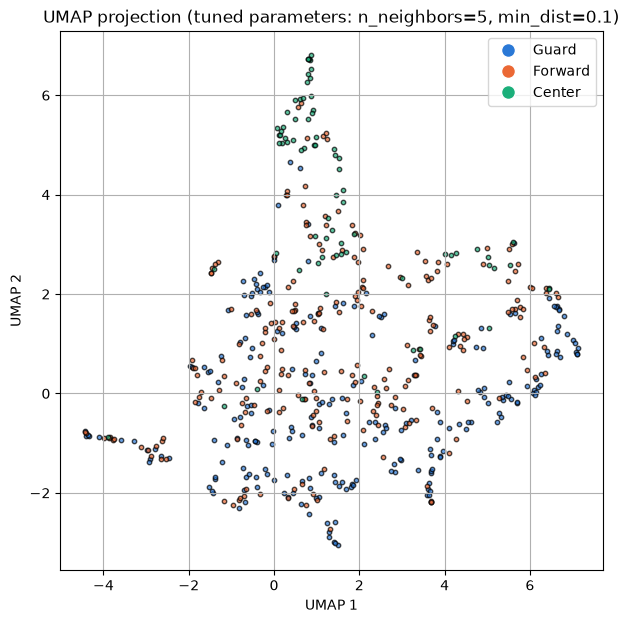

In [27]:
tunedEmb = umap.UMAP(n_neighbors=5, min_dist=0.1, random_state=42).fit_transform(Z)

plt.figure(figsize=(7, 7))
fig, ax = plt.subplots(figsize=(7, 7))

# Plotting for positions
for g in ['Guard', 'Forward', 'Center']:
    mask = broadPositions == g
    ax.scatter(tunedEmb[mask, 0], tunedEmb[mask, 1], s=10, alpha=0.7, edgecolor='k', c=posColors[g], label=g)
ax.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=posColors[g], markersize=10) for g in ['Guard', 'Forward', 'Center']],
           labels=['Guard', 'Forward', 'Center'])
ax.set_title('UMAP projection (tuned parameters: n_neighbors=5, min_dist=0.1)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.grid(True)
plt.show()


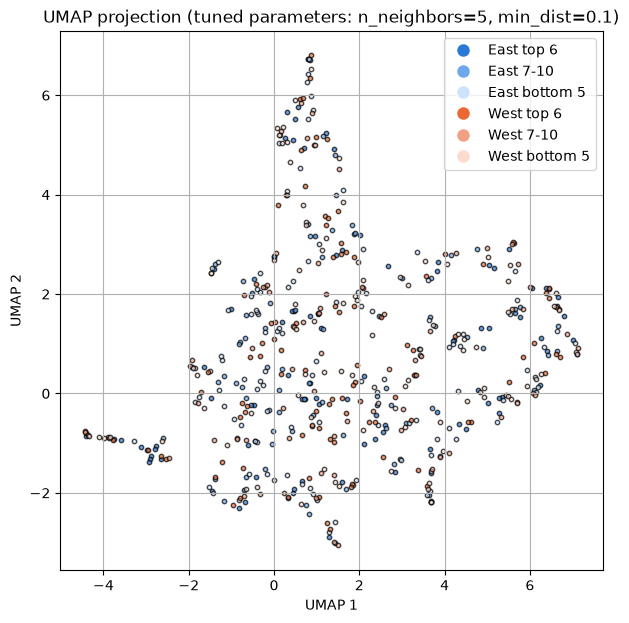

In [28]:
#plotting for team tiers
plt.figure(figsize=(7, 7))  
for g, color in teamColors.items():
    mask = teamBucket == g
    plt.scatter(tunedEmb[mask, 0], tunedEmb[mask, 1], s=10, alpha=0.7, edgecolor='k', c=color, label=g)
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for g, color in teamColors.items()],
           labels=[g for g, color in teamColors.items()])
plt.title('UMAP projection (tuned parameters: n_neighbors=5, min_dist=0.1)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()


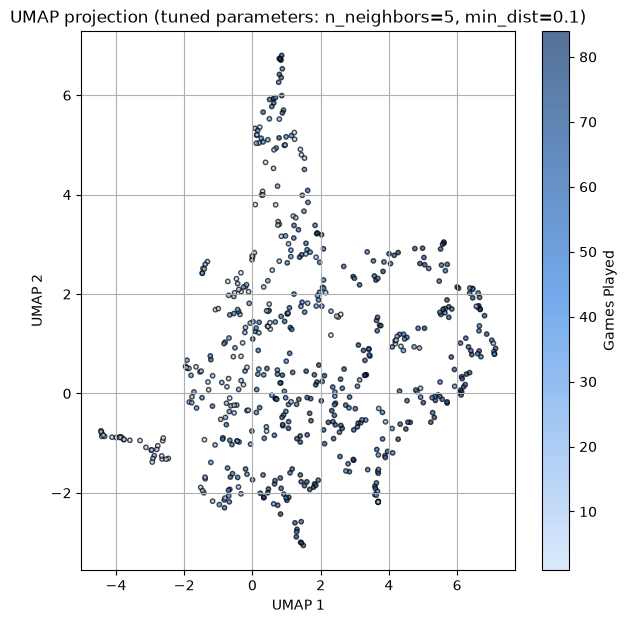

In [29]:
# plotting for games played

plt.figure(figsize=(7, 7))  
blues = LinearSegmentedColormap.from_list('blues', ['#cde2fb','#3987e5','#0d366b'])
scatter = plt.scatter(tunedEmb[:, 0], tunedEmb[:, 1], s=10, alpha=0.7, edgecolor='k', c=gamesPlayed, cmap=blues)
plt.colorbar(scatter, label='Games Played')
plt.title('UMAP projection (tuned parameters: n_neighbors=5, min_dist=0.1)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()

### Problem 5b (5 points)

What is the pattern that you observe?  Explain the best visualization that you have found using UMAP.

The best story UMAP is telling us is the one of playing time. As we go higher in the dimensions of the map we see we see darker blue colors which implies more games are played. 
Plotting for teams looks like noise which different bucket of teams popping up in different sections of the graph. 
Postions will be a close second after games played, as we do player postions appearing in clusters. 

## Problem 6 (20 points)  

### Problem 6a (10 points)

Storytelling is an important skill in AI/ML according to your classmates.  Obtain a multidimensional dataset that interests you with at least several features and 100s of rows. Ideally find or create your own dataset from something meaningful for you. However, there are some common locations:

Some good sources are:
* https://www.data-is-plural.com/
* https://www.kaggle.com
* https://archive.ics.uci.edu/ the UCI Machine Learning Repository

The dataset should be public so provide a link to the data.

**Note**: We consider the iris dataset to be too small in that it has only 150 rows and 4 columns. Plus, it has a boring story. We're looking for more interesting datasets where you can tell a meaningful story from the analysis. It should not be massive in terms of number of rows or columns since these may cause overly dense scatter plots or suffer dimensionality reduction challenges, respectively. It should have at least 1000 numbers minimum. 

We consider the wine dataset to be interesting, but it's so widely used in PCA types of analyses that we would like you to find something else. 

Explore dimensionality reduction methods that provide you with the best insight.  Although it may not be your best method, try at least a PCA (although you are welcome to use the sklearn.decomposition.PCA version) as well as at least a more advanced approach.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# data source: https://www.kaggle.com/datasets/hubertsidorowicz/football-players-stats-2024-2025

import kagglehub

# Download latest version
path = kagglehub.dataset_download("hubertsidorowicz/football-players-stats-2024-2025")

print("Path to dataset files:", path)

#soccer player stats from kaggle : player information from europe's top 5 leagues
# I decided to use the soccer dataset even though the data set used above is also sports related. 
# I wanted to use this data set to reinforce my learning since this is a sport I am more familiar with.
df = pd.read_csv(path + "/players_data_light-2024_2025.csv")


#Data cleaning, I find this section of the work quite intense and required AI coaching and elaboration
numericAll = df.select_dtypes(include=[np.number])
gkOnly     = [c for c in numericAll.columns if numericAll[c].isna().mean() > 0.5] # goalkkeeper only stats was missing for a lot of the players and hence made them less useful
duplicated = [c for c in numericAll.columns
              if re.search(r'_stats_(keeper|shooting|playing_time|misc)$', c)]

# Identify candidate columns for further analysis by excluding goalkeeper-only stats and duplicated stats
candidates = [c for c in numericAll.columns
              if c not in set(gkOnly) | set(duplicated) and c not in ('Rk', 'Born')]

# keep columns that are at least 90% populated, then drop the few incomplete rows
keepCols     = [c for c in candidates if df[c].isna().mean() <= 0.10]
cleanNumeric = df[keepCols].dropna()

print(cleanNumeric.shape)

survived = cleanNumeric.index

pos = df.loc[survived, 'Pos'].str.strip(',').str[0] # Some players have multiple positions, we take the first one
leauge = df.loc[survived, 'Comp'] # league information for the survived players
team = df.loc[survived, 'Squad']
player = df.loc[survived, 'Player']







Path to dataset files: /Users/ayoolanjoku/.cache/kagglehub/datasets/hubertsidorowicz/football-players-stats-2024-2025/versions/43
(2621, 107)


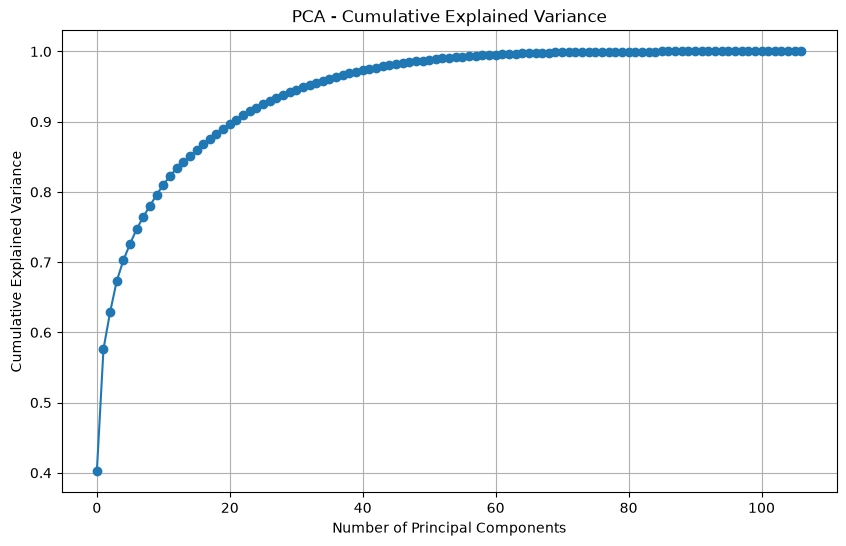

In [31]:
#standarsinzing and running PCA

scaler = StandardScaler()
scaledData = scaler.fit_transform(cleanNumeric)

pca = PCA()
pcaData = pca.fit_transform(scaledData)

explainedVariance = pca.explained_variance_ratio_
cumulativeVariance = np.cumsum(explainedVariance)

plt.figure(figsize=(10, 6))
plt.plot(cumulativeVariance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.show()

# this plot is explaining how much variencae is capture by each principal component

In [32]:
soccerVarianceRatio = explainedVariance / explainedVariance.sum()
soccerCumulativeVar = np.cumsum(soccerVarianceRatio)
for k in range(5):
    print('PC%-2d  %5.1f%%   cumulative %5.1f%%'
          % (k+1, 100*soccerVarianceRatio[k], 100*soccerCumulativeVar[k]))
print('\nComponents for 80%%: %d' % (np.searchsorted(soccerCumulativeVar, 0.80) + 1)) # how many components are needed to explain 80% of the variance
print('Components for 90%%: %d' % (np.searchsorted(soccerCumulativeVar, 0.90) + 1)) # how many components are needed to explain 90% of the variance

# in this dataset pc1 takes roughly 40.2% of the variance

PC1    40.2%   cumulative  40.2%
PC2    17.4%   cumulative  57.6%
PC3     5.3%   cumulative  62.9%
PC4     4.5%   cumulative  67.4%
PC5     2.9%   cumulative  70.3%

Components for 80%: 11
Components for 90%: 22


In [33]:
# figuring out how the fetures affect pc1

pc1Loadings = pca.components_[0]
order = np.argsort(-np.abs(pc1Loadings))     # sort by magnitude, ignoring sign
soccerNumCols = cleanNumeric.columns
print('PC1 loadings, by magnitude:')
for k in order:
    print('  %-5s %+.3f' % (soccerNumCols[k], pc1Loadings[k]))

PC1 loadings, by magnitude:
  SCA   +0.141
  PassLive +0.141
  Att 3rd_stats_possession +0.136
  KP    +0.132
  Recov +0.132
  1/3_stats_possession +0.130
  PrgP_stats_passing +0.130
  PrgP  +0.130
  TotDist_stats_possession +0.129
  PPA   +0.128
  xA    +0.128
  Rec   +0.128
  Min   +0.127
  90s   +0.127
  Starts +0.127
  Touches +0.126
  Live_stats_possession +0.126
  MP    +0.126
  GCA   +0.126
  Carries +0.125
  xAG   +0.125
  xAG_stats_passing +0.125
  PrgC  +0.124
  PrgC_stats_possession +0.124
  PrgDist_stats_possession +0.121
  Pass  +0.120
  Att   +0.119
  Mid 3rd_stats_possession +0.119
  Live  +0.118
  Att_stats_defense +0.116
  Lost  +0.115
  Mis   +0.114
  PrgR  +0.114
  PrgR_stats_possession +0.114
  npxG+xAG +0.113
  Tkl   +0.113
  Ast   +0.113
  Ast_stats_passing +0.113
  Cmp_stats_passing_types +0.112
  Cmp   +0.112
  Sh    +0.112
  Succ  +0.112
  Att_stats_possession +0.112
  TklW  +0.112
  Att 3rd +0.110
  Tkl+Int +0.110
  Blocks_stats_defense +0.110
  1/3   +0.109
 

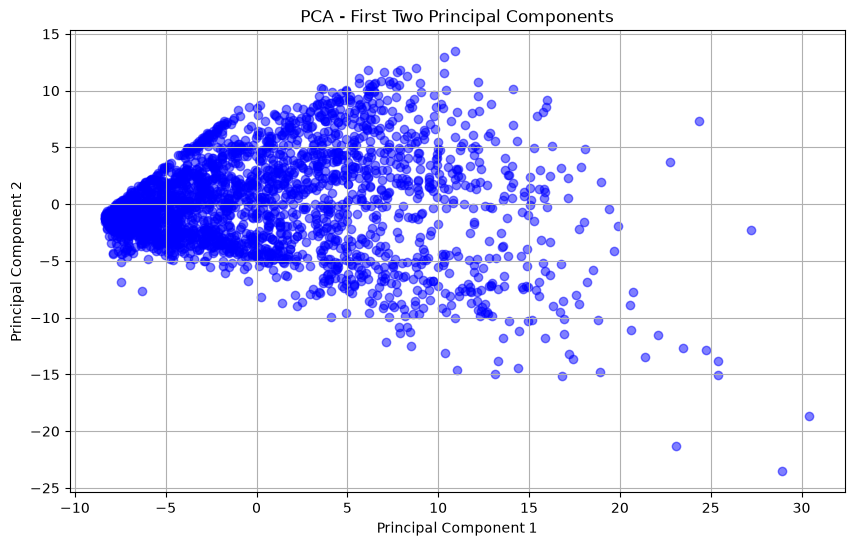

In [34]:
pc1 = pcaData[:, 0]
pc2 = pcaData[:, 1]


plt.figure(figsize=(10, 6))
plt.scatter(pc1, pc2, c='blue', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - First Two Principal Components')
plt.grid(True)
plt.show()

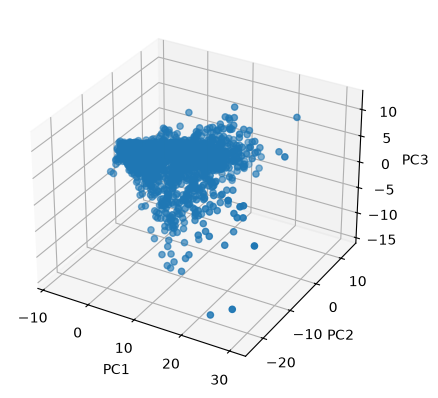

In [35]:
#plotting a 3d principal component analysis
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pc1, pc2, pcaData[:,2]) # pcaData[:,2] is pc3
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

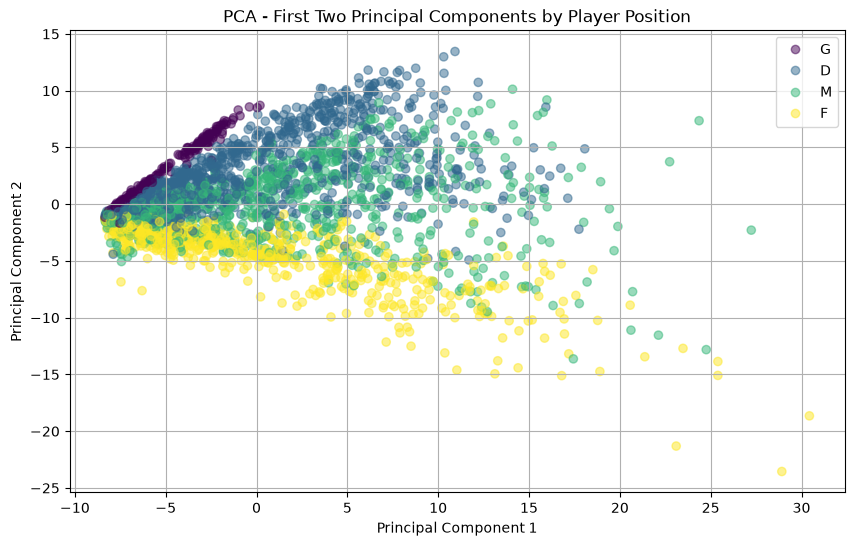

In [36]:
#attempting to visualize the first two principal components with player positions as color coding
plt.figure(figsize=(10, 6))
scatter = plt.scatter(pc1, pc2, c=pos.map({'G':0, 'D':1, 'M':2, 'F':3}), alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - First Two Principal Components by Player Position')
plt.grid(True)
plt.legend(handles=scatter.legend_elements()[0], labels=['G', 'D', 'M', 'F'])
plt.show()

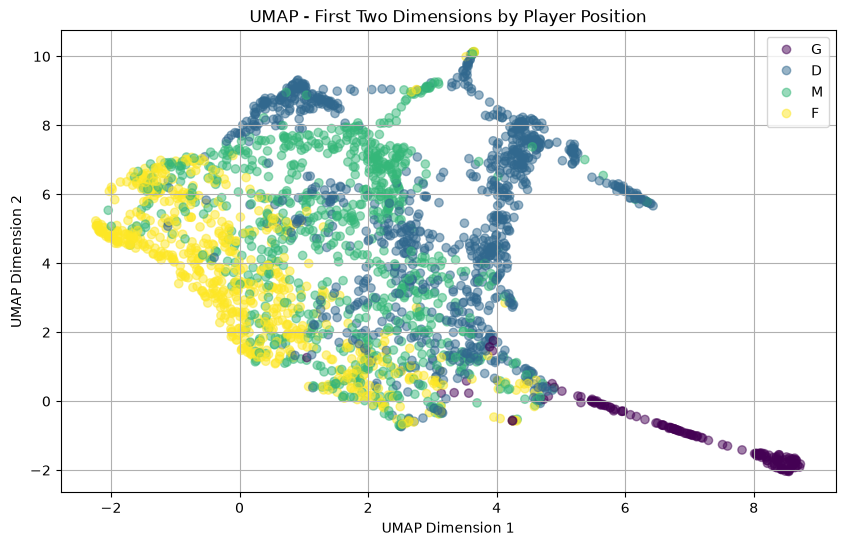

In [37]:
# Using umap for dimensionality reduction and visualization
import umap

reducer = umap.UMAP()
embedding = reducer.fit_transform(scaledData)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=pos.map({'G':0, 'D':1, 'M':2, 'F':3}), alpha=0.5)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP - First Two Dimensions by Player Position')
plt.legend(handles=scatter.legend_elements()[0], labels=['G', 'D', 'M', 'F'])
plt.grid(True)
plt.show()

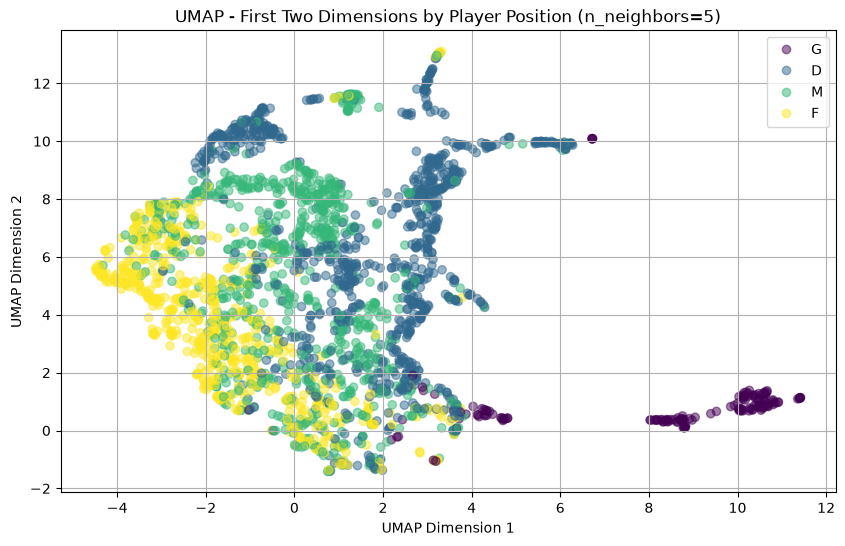

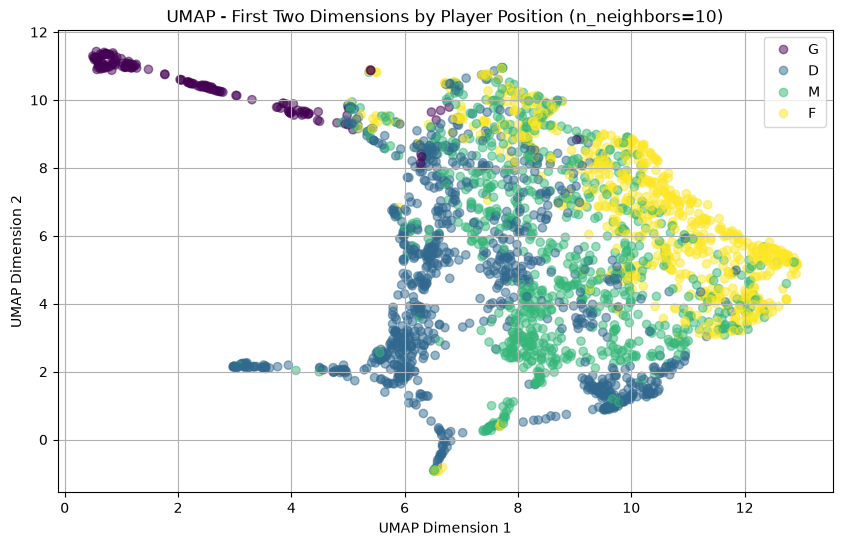

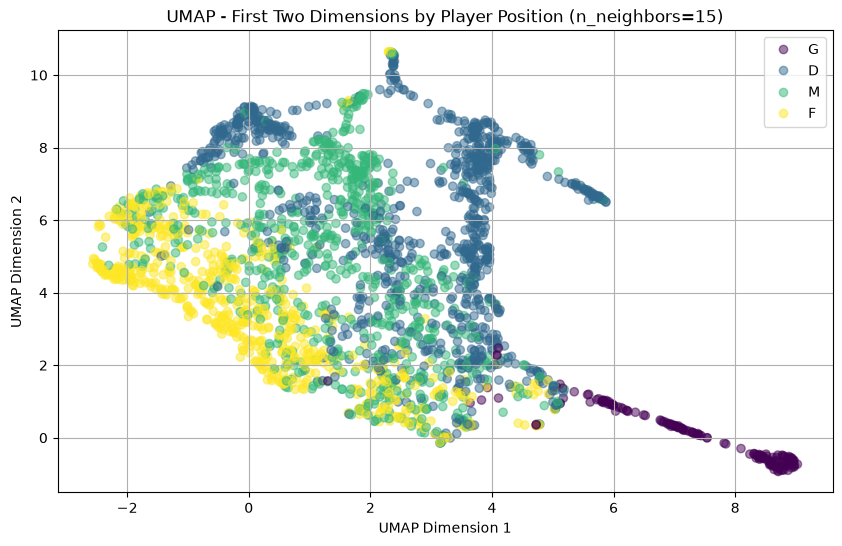

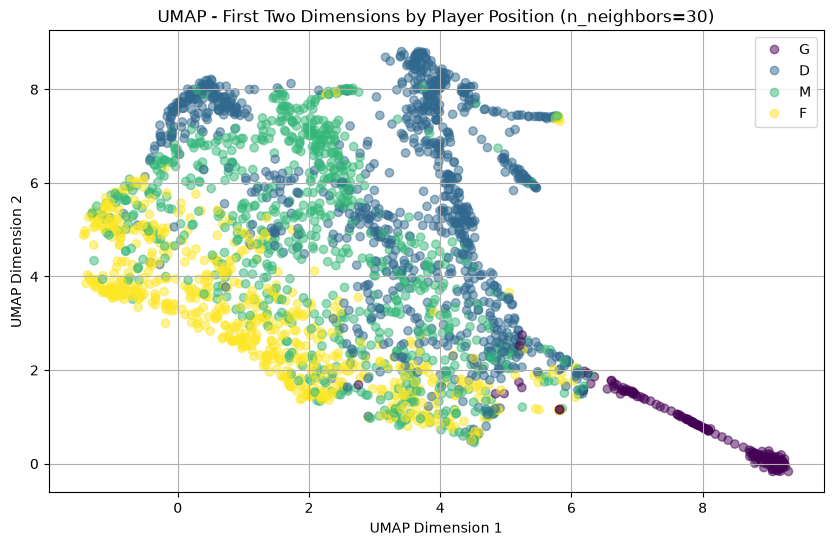

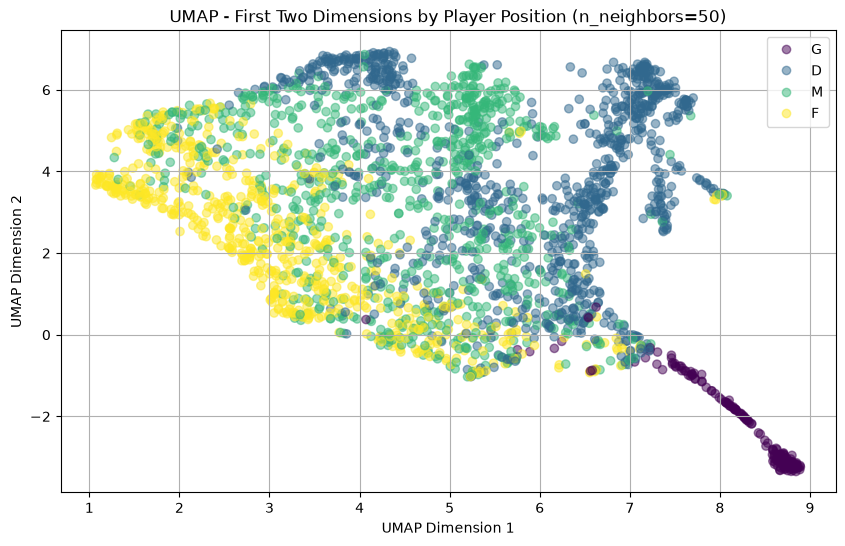

In [38]:
#looping through different n-neighbors for UMAP
for n_neighbors in [5, 10, 15, 30, 50]:
    reducer = umap.UMAP(n_neighbors=n_neighbors)
    embedding = reducer.fit_transform(scaledData)

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=pos.map({'G':0, 'D':1, 'M':2, 'F':3}), alpha=0.5)
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.title(f'UMAP - First Two Dimensions by Player Position (n_neighbors={n_neighbors})')
    plt.legend(handles=scatter.legend_elements()[0], labels=['G', 'D', 'M', 'F'])
    plt.grid(True)
    plt.show()

### Problem 6b (10 points)

Tell us the story of your best visualization. You can assume that we know nothing about the data and you are telling us what you have learned about it from visualization methods alone (i.e. no clustering or other analyses).

**PCA Explanation**

First I would restate that PC1 is making up about 40% of the cumulative variance, with PC2 having 17%. 

What I'm strugling with is that this dataset haas a lot of columns > 160. With that it is challenging for me to see how each feature directly affects the plot. I can only make assumptions based off my general knowdlege of the sport.


**Explaning the visualization with UMAP**

Umap map is doing a good job in trying to tell us **something**. The visualization is pretty consistent even when we change n-neighbors making it more localized or globalized.

From my understanding of soccer, one could maybe use these umap graphs to possibly explain defensive actions by positions. With the goalkeepers (G) and Defenders(D) having more creative actions than forwards (F) and midfeilders (M).



## Problem 7 (5 points)

### Problem 7a  How many hours did this homework take? (2 points)  

Credit for submission.  This will not affect your grade (unless you don't answer it).  We will be monitoring time spent on homework to be sure that we are not over-burdening students.

In [39]:
#15 hours

### Problem 7b (3 points) 

Save this notebook as LastnameFirstnameHW1.ipynb such as MuskElonHW1.ipynb.  Create a pdf of the notebook named similarly.  Submit both the python notebook and the pdf version to the Canvas dropbox.  We require both versions.